# Data EDA
### Questions: to ask: 
- Where are the segmentations masks or are we supposed to always use the same?

### Minimum viable product (passing grade):Implementing, Training, and Evaluating the IVAE Model on Brain MRI Data

1. **Implementing a Dataset Class**
    - How can we implement a dataset class that loads 2D slices of the brain MRIs (e.g., the middle slice) across a given axis (e.g., the coronal axis), along with the corresponding labels (age, sex, dementia status)?

2. **Model Architectures**
    - How can we implement the encoder, decoder, and prior_encoder model architectures?
    - How can we ensure that the encoder and decoder are powerful enough to sufficiently model the images (e.g., based on the ResNet architectures)?
    - (Example code for ResNet encoders and decoders: [ResNet Components](https://github.com/LightningUniverse/lightning-bolts/blob/master/src/pl_bolts/models/autoencoders/components.py))
    - Ideas: Keras seems to work too: https://github.com/christianversloot/machine-learning-articles/blob/main/how-to-create-a-variational-autoencoder-with-keras.md

3. **Measuring Training Progress**
    - How can we implement essential ways of measuring training progress?
        - How should we log each loss and sub-loss (e.g., `train/loss`, `val/loss`, `train/reconstruction_loss`, `train/kld_loss`, etc.)?
        - How can we plot the reconstructions of a few validation samples across training (ensuring the same samples are selected for each epoch)?
        - How can we log all these measures to a tool like Weights & Biases (or similar)?

4. **Cross-Validation and Hyperparameter Tuning**
    - How can we implement subject-out cross-validation?
    - How can we perform a simple hyperparameter grid search across 5 folds to find the highest possible weight for the Kullback-Leibler (KL) divergence loss, where the model still achieves reasonable reconstruction?

In [ ]:
import os
import sys
import shutil
from torch import nn
import nibabel as nib
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from collections import defaultdict
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch
from torchvision import transforms
from matplotlib.widgets import Slider
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
# conda create -n tf-gpu tensorflow-gpu
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Conv3D, Conv3DTranspose, Dense, Flatten, Reshape, Lambda
import tensorflow as tf
sys.path.append('/dhc/home/laura.spies/DVA4D/notebooks')
from utils import resnet18_encoder, resnet18_decoder, ResNetEncoder, EncoderBlock, ResNetDecoder, DecoderBlock

In [62]:
#subject_root = Path('data/dementia_df.csv')
subject_root = Path('../data/dementia_df.csv')
assert subject_root.exists()

print("Current working directory:", os.getcwd())

Current working directory: /dhc/home/laura.spies/DVA4D/notebooks


In [64]:
""" Step 1: Load the dataset """ 
# Renamed the slack df to dementia_df for better readability and added to data folder
dementia_df = pd.read_csv('data/dementia_df.csv')
# dementia_df = pd.read_csv('../data/dementia_df.csv')
# print(dementia_df.columns)

# print(dementia_df.path.iloc[0])
# print(dementia_df.path.iloc[1])

# Create a subset of the dementia_df 
test_ids = ['018_S_0450', '002_S_0413', '002_S_0559', '002_S_0295']

# 
test_df =  dementia_df[dementia_df['Subject'].isin(test_ids)]
# Test = dementia_dat.columns[['Subject','Group', 'path']]
test_df=test_df[['Subject','Group', 'path', 'Age', 'Sex']]

# For local path  the old root path and the new root path
"""
old_path = 'dhc/groups/fglippert/adni_t1_mprage'
new_path = 'AML/DVA4D'

# Apply replacement directly to the 'path' column in the DataFrame
test_df['path'] = test_df['path'].str.replace(old_path, new_path, regex=False)

# Display modified DataFrame
dementia_df
"""
test_df

,Subject,Group,path,Age,Sex
3009,002_S_0559,CN,/dhc/groups/fglippert/adni_t1_mprage/002_S_055...,82,M
3010,002_S_0559,CN,/dhc/groups/fglippert/adni_t1_mprage/002_S_055...,82,M
3753,002_S_0413,CN,/dhc/groups/fglippert/adni_t1_mprage/002_S_041...,82,F
3754,002_S_0413,CN,/dhc/groups/fglippert/adni_t1_mprage/002_S_041...,84,F
3755,002_S_0413,CN,/dhc/groups/fglippert/adni_t1_mprage/002_S_041...,85,F
3756,002_S_0413,CN,/dhc/groups/fglippert/adni_t1_mprage/002_S_041...,83,F
3757,002_S_0413,CN,/dhc/groups/fglippert/adni_t1_mprage/002_S_041...,82,F
3758,002_S_0413,CN,/dhc/groups/fglippert/adni_t1_mprage/002_S_041...,82,F
3759,002_S_0413,CN,/dhc/groups/fglippert/adni_t1_mprage/002_S_041...,83,F
3760,002_S_0413,CN,/dhc/groups/fglippert/adni_t1_mprage/002_S_041...,82,F


In [65]:
def collate_fn(batch):
    max_visits = max(patient_data.shape[0] for patient_data, _ in batch)

    padded_images = []
    padded_labels = []

    for patient_data, patient_labels in batch:
        padding_images = max(0, max_visits - patient_data.shape[0])  # Ensure non-negative
        padded_images.append(
            torch.cat([patient_data, torch.zeros(padding_images, *patient_data.shape[1:])], dim=0)
        )
        padded_patient_labels = patient_labels + [None] * padding_images
        padded_labels.append(padded_patient_labels)

    return torch.stack(padded_images), padded_labels

In [76]:
"""
Task 1: Implementing a dataset class, which loads 2D slices of the brain MRIs (e.g., 
the middle slice) across a given axis (e.g., the coronal axis), along with the 
corresponding labels (age, sex, dementia status)

"""
class DementiaPatientDataset(Dataset):
    def __init__(self, dataframe, axis="coronal", max_visits=None, transform=None):
        self.axis = axis
        self.transform = transform
        self.patient_data = defaultdict(list)

        # Group data by patient
        for _, row in dataframe.iterrows():
            self.patient_data[row['Subject']].append(row)

        # Sort visits for each patient by visit date
        for subject in self.patient_data:
            self.patient_data[subject] = sorted(
                self.patient_data[subject], key=lambda x: x['Visit']
            )

        self.group_mapping = {
            "CN": 0, "MCI": 0, "EMCI": 1, "LMCI": 1, "AD": 1, "SMC": 1, "Patient": 2
        }

        self.max_visits = max_visits or max(len(visits) for visits in self.patient_data.values())
        self.patients = list(self.patient_data.keys())

    def __len__(self):
        return len(self.patients)

    def __getitem__(self, idx):
        patient_id = self.patients[idx]
        patient_visits = self.patient_data[patient_id]

        images = []
        labels = []

        for visit in patient_visits[:self.max_visits]:
            image_path = visit['path']
            nifti_data = nib.load(image_path).get_fdata()

            # Extract a 2D slice
            if self.axis == "coronal":
                slice_idx = nifti_data.shape[1] // 2
                img_slice = nifti_data[:, slice_idx, :]
            elif self.axis == "sagittal":
                slice_idx = nifti_data.shape[0] // 2
                img_slice = nifti_data[slice_idx, :, :]
            elif self.axis == "axial":
                slice_idx = nifti_data.shape[2] // 2
                img_slice = nifti_data[:, :, slice_idx]
            else:
                raise ValueError(f"Invalid axis: {self.axis}")

            # Normalize slice
            img_slice = (img_slice - img_slice.min()) / (img_slice.max() - img_slice.min() + 1e-5)

            # Convert to tensor and add channel dimension
            img_slice = torch.tensor(img_slice, dtype=torch.float32).unsqueeze(0)

            # Apply transformations
            if self.transform:
                img_slice = self.transform(img_slice)

            images.append(img_slice)

            # Map 'Group' to numeric values
            dementia_status = self.group_mapping[visit['Group']]
            labels.append({
                'age': torch.tensor(visit['Age'], dtype=torch.float32),
                'sex': torch.tensor(1 if visit['Sex'] == 'F' else 0, dtype=torch.long),
                'dementia_status': torch.tensor(dementia_status, dtype=torch.long)
            })

        # Padding for visits
        padding_images = max(0, self.max_visits - len(images))
        if len(images) > 0:
            images += [torch.zeros_like(images[0])] * padding_images
        labels += [None] * padding_images

        return torch.stack(images), labels


In [ ]:
# Augmentations and DataLoader?
augmentation_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.Normalize(mean=[0.5], std=[0.5])  # Normalize for grayscale
])

dataset = DementiaPatientDataset(dataframe=dementia_df, axis="coronal", max_visits=10, transform=augmentation_transforms)
data_loader = DataLoader(dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)

# Test DataLoader
for idx, (batch_images, batch_labels) in enumerate(data_loader):
    print(f"Batch {idx + 1}")
    print(f"Batch image shape: {batch_images.shape}")  # Should include (Batch, Max Visits, Channels, Height, Width)
    print(f"Batch labels: {batch_labels}")
    break

In [68]:
def visualize_patient_data(images, labels, patient_id=None):
    images = images.squeeze(1)  # Shape: (visits, H, W)
    num_visits = len(labels)

    # Create a figure with subplots for each visit
    fig, axes = plt.subplots(1, num_visits, figsize=(15, 5))
    if num_visits == 1:
        axes = [axes]  # Ensure axes is iterable for a single visit

    for i, ax in enumerate(axes):
        ax.imshow(images[i].numpy(), cmap="gray")
        ax.axis("off")

        metadata = labels[i]
        if metadata:
            text = (
                f"Age: {metadata['age'].item()}\n"
                f"Sex: {'Female' if metadata['sex'].item() == 1 else 'Male'}\n"
                f"Dementia: {metadata['dementia_status'].item()}"
            )
        else:
            text = "No Data"
        ax.set_title(text, fontsize=10)


    if patient_id:
        plt.suptitle(f"Patient ID: {patient_id}", fontsize=16)

    plt.tight_layout()
    plt.show()

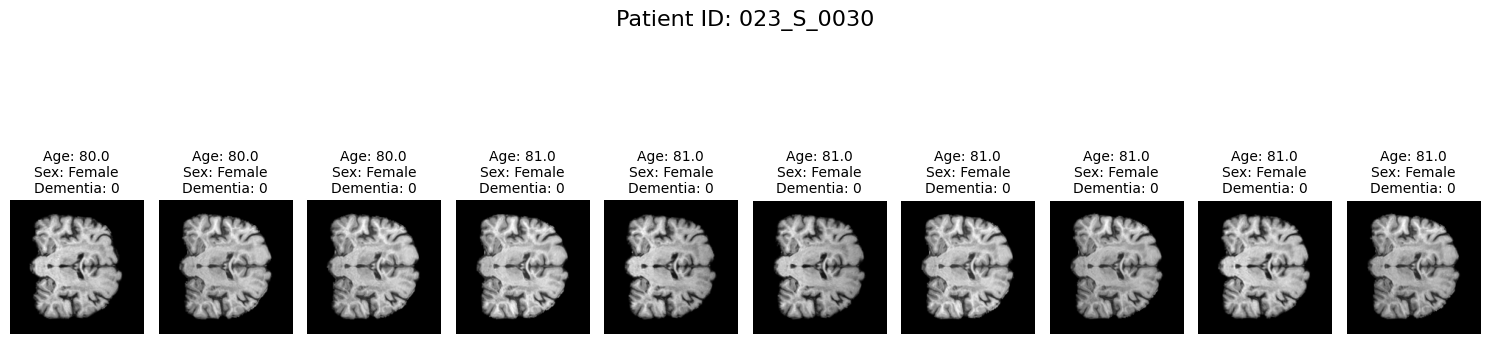

In [45]:
patient_images, patient_labels = dataset[1]  # switch patient index
patient_id = dataset.patients[1]

visualize_patient_data(patient_images, patient_labels, patient_id=patient_id)

In [69]:
class NIfTIDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df[df['Group'] != 'Patient']
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Retrieve row from the DataFrame
        row = self.df.iloc[idx]
        nifti_path = row['path']
        metadata = {
            "Age": row['Age'],
            "Sex": row['Sex'],  # 1 for Female, 0 for Male
            "Group": row['Group'],  # 1 for Yes, 0 for No
        }

        # Load NIfTI file and extract 2D slices
        nifti_data = nib.load(nifti_path).get_fdata()
        slices = [nifti_data[:, :, i] for i in range(nifti_data.shape[2])]

        # Normalize each slice and convert to tensor
        images = []
        for slice_ in slices:
            slice_ = (slice_ - np.min(slice_)) / (np.max(slice_) - np.min(slice_))  # Normalize to [0, 1]
            slice_tensor = torch.tensor(slice_, dtype=torch.float32).unsqueeze(0)  # Add channel dimension
            if self.transform:
                slice_tensor = self.transform(slice_tensor)
            images.append(slice_tensor)

        return torch.stack(images), metadata

In [70]:
dataset = NIfTIDataset(test_df)
latent_dim = 128
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

# Initialize the encoder and decoder
def resnet18_encoder(first_conv, maxpool1):
    return ResNetEncoder(EncoderBlock, [2, 2, 2, 2], first_conv, maxpool1)

def resnet18_decoder(latent_dim, input_height, first_conv, maxpool1):
    return ResNetDecoder(DecoderBlock, [2, 2, 2, 2], latent_dim=latent_dim, input_height=64, first_conv=False, maxpool1=False)

encoder = resnet18_encoder(first_conv=False, maxpool1=False)
decoder = resnet18_decoder(latent_dim=latent_dim, input_height=64, first_conv=False, maxpool1=False)

for batch in dataloader:
    images, metadata = batch
    # Images: Tensor of shape (batch_size, slices, 1, H, W)
    # Metadata: List of dictionaries containing age, sex, dementia_status
    print("Images shape:", images.shape)
    print("Metadata:", metadata)
    break

/home/scratch/laura.spies/1003383/ipykernel_867853/875999155.py:26: RuntimeWarning: invalid value encountered in divide
  slice_ = (slice_ - np.min(slice_)) / (np.max(slice_) - np.min(slice_))  # Normalize to [0, 1]


Images shape: torch.Size([1, 182, 1, 182, 218])
Metadata: {'Age': tensor([82]), 'Sex': ['M'], 'Group': ['CN']}


In [ ]:
print('Hello Connection are you still there")

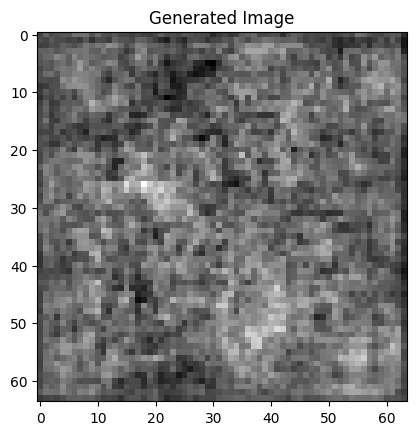

In [ ]:
latent_vector = torch.randn(1, latent_dim)  
generated_image = decoder(latent_vector).detach().cpu() 

plt.imshow(generated_image[0, 0, :, :].numpy(), cmap='gray')
plt.title("Generated Image")
plt.show()

In [12]:
def visualize_patient_data(images, labels, patient_id=None):
    images = images.squeeze(1)  # Remove the channel dimension
    num_visits = len(labels)

    # Create subplots for each visit
    fig, axes = plt.subplots(1, num_visits, figsize=(15, 5))
    if num_visits == 1:
        axes = [axes]  # Ensure axes is iterable for a single visit

    for i, ax in enumerate(axes):
        ax.imshow(images[i].numpy(), cmap="gray")
        ax.axis("off")

        metadata = labels[i]
        if metadata:
            text = (
                f"Age: {metadata['age'].item():.0f}\n"
                f"Sex: {'Female' if metadata['sex'].item() == 1 else 'Male'}\n"
                f"Dementia: {'Yes' if metadata['dementia_status'].item() == 1 else 'No'}"
            )
        else:
            text = "No Data"
        ax.set_title(text, fontsize=10)

    if patient_id:
        plt.suptitle(f"Patient ID: {patient_id}", fontsize=16)

    plt.tight_layout()
    plt.show()

Resolved path: /dhc/groups/fglippert/adni_t1_mprage/002_S_0295/MPRAGE/2012-05-10_15_44_50.0/S150055/T1toMNInonlin.nii.gz


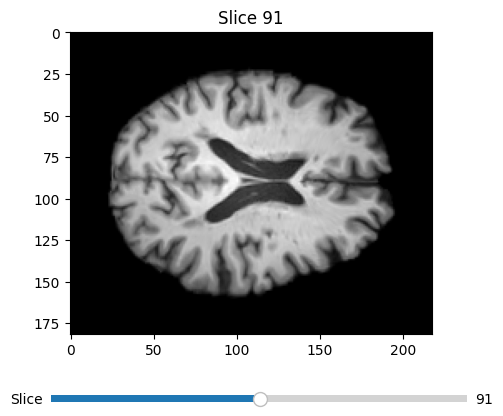

In [15]:
# Define the path using Path for compatibility
nifti_path = Path('/dhc/groups/fglippert/adni_t1_mprage/002_S_0295/MPRAGE/2012-05-10_15_44_50.0/S150055/T1toMNInonlin.nii.gz').resolve()
print("Resolved path:", nifti_path)

if not nifti_path.exists():
    raise FileNotFoundError(f"The file was not found at: {nifti_path}")

# Load the NIfTI image (compressed .nii.gz format)
nifti_img = nib.load(str(nifti_path))  # Convert Path to string if nibabel requires it
image_data = nifti_img.get_fdata()

# Check if the image is 3D
if len(image_data.shape) != 3:
    raise ValueError("The NIfTI image is not 3D. Please provide a 3D image.")

# Initial setup for the figure and axes
fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.25)
slice_index = image_data.shape[2] // 2  # Start with the middle slice

# Display the initial slice
slice_image = ax.imshow(image_data[:, :, slice_index], cmap="gray")
ax.set_title(f"Slice {slice_index}")

# Slider setup
ax_slider = plt.axes([0.2, 0.1, 0.65, 0.03], facecolor="lightgray")
slice_slider = Slider(ax_slider, "Slice", 0, image_data.shape[2] - 1, valinit=slice_index, valstep=1)

# Update function for the slider
def update(val):
    slice_idx = int(slice_slider.val)
    slice_image.set_data(image_data[:, :, slice_idx])
    ax.set_title(f"Slice {slice_idx}")
    fig.canvas.draw_idle()

# Connect the slider to the update function
slice_slider.on_changed(update)

plt.show()

In [10]:
# metadata
header = nifti_img.header
print(header)

<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 16384
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3 182 218 182   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float32
bitpix          : 32
slice_start     : 0
pixdim          : [-1.  1.  1.  1.  1.  1.  1.  1.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'6.0.5:9e026117'
aux_file        : b''
qform_code      : mni
sform_code      : mni
quatern_b       : 0.0
quatern_c       : 1.0
quatern_d       : 0.0
qoffset_x       : 90.0
qoffset_y       : -126.0
qoffset_z       : -72.0
srow_x          : [-1.  0.  0

In [7]:
# Functions
def convert_to_nifti(image_path, nifti_path):
    try:
        img = nib.load(image_path)
        nib.save(img, nifti_path)  # Save as NIfTI format
        # print(f"Successfully converted {image_path} to {nifti_path}")
    except FileNotFoundError:
        print(f"Error: File {image_path} not found. Ensure you're connected to the cluster.")
    except Exception as e:
        print(f"An error occurred while processing {image_path}: {e}")

def preprocess_image(image_path):
    img = nib.load(image_path).get_fdata() 
    # img = np.resize(img, (128, 128, 1))
    img = (img - np.mean(img)) / np.std(img)
    return img

def preprocess_metadata(df):
    # Standardize or one-hot encode features as needed
    df['Age'] = StandardScaler().fit_transform(df[['Age']])
    df = pd.get_dummies(df, columns=['Sex', 'Group'], drop_first=True)
    return df

def sampling(args):
    z_mean, z_log_var = args
    batch = K.shape(z_mean)[0]
    dim = K.int_shape(z_mean)[1]
    epsilon = K.random_normal(shape=(batch, dim))
    return z_mean + K.exp(0.5 * z_log_var) * epsilon

def tf_preprocess_image(path):
    img = tf.io.read_file(path)
    img = tf.img.decode_image(image, channels = 1)
    img = tf.img.resize(image, [128, 128])
    img = img / 255.0 # Normalize [0,1]
    return img

In [8]:
# Load the NIfTI image (compressed .nii.gz format)

# Check if the image is 3D
if len(image_data.shape) != 3:
    raise ValueError("The NIfTI image is not 3D. Please provide a 3D image.")

for i, row in test_df.iterrows():
    image_path = row['path']
    convert_to_nifti(image_path, nifti_path)
    test_df.at[i, 'path'] = nifti_path  # Update path to NIfTI

In [9]:
# Step 4: Splitting the dataset
# Task: Stratify by patients : age, train validation and test 
# Currently runs by picture, is okay for the test of pipeline 
train_data, test_data = train_test_split(test_df, test_size=0.2, random_state=42)
train_data

,Subject,Group,path
11474,002_S_0295,CN,/dhc/groups/fglippert/adni_t1_mprage/002_S_029...
11471,002_S_0295,CN,/dhc/groups/fglippert/adni_t1_mprage/002_S_029...
11473,002_S_0295,CN,/dhc/groups/fglippert/adni_t1_mprage/002_S_029...


In [21]:
# Step 5: Build the (Disentangled) VAE with tensorflow
# NIfTI images are three D!!!

# Parameters
latent_dim = 10
input_shape = (64, 64, 64, 1)  # 3D shape for each volume patch

# Define Encoder
inputs = Input(shape=input_shape)
x = Conv3D(32, (3, 3, 3), activation='relu', strides=2, padding='same')(inputs)
x = Conv3D(64, (3, 3, 3), activation='relu', strides=2, padding='same')(x)
x = Conv3D(128, (3, 3, 3), activation='relu', strides=2, padding='same')(x)
x = Flatten()(x)
z_mean = Dense(latent_dim)(x)
z_log_var = Dense(latent_dim)(x)
z = Lambda(sampling, output_shape=(latent_dim,))([z_mean, z_log_var])

# Sampling
z = Lambda(sampling, output_shape=(latent_dim,))([z_mean, z_log_var])

# Define Decoder
decoder_input = Input(shape=(latent_dim,))
x = Dense(8 * 8 * 8 * 128, activation='relu')(decoder_input)
x = Reshape((8, 8, 8, 128))(x)
x = Conv3DTranspose(128, (3, 3, 3), activation='relu', strides=2, padding='same')(x)
x = Conv3DTranspose(64, (3, 3, 3), activation='relu', strides=2, padding='same')(x)
x = Conv3DTranspose(32, (3, 3, 3), activation='relu', strides=2, padding='same')(x)
outputs = Conv3DTranspose(1, (3, 3, 3), activation='sigmoid', padding='same')(x)

# Compile VAE
encoder = Model(inputs, [z_mean, z_log_var, z], name="encoder")
decoder = Model(decoder_input, outputs, name="decoder")
vae = Model(inputs, decoder(encoder(inputs)[2]), name="vae")

# Define VAE loss
reconstruction_loss = tf.reduce_mean(tf.square(inputs - vae(inputs)))
kl_loss = -0.5 * tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=-1)
vae_loss = tf.reduce_mean(reconstruction_loss + kl_loss)
vae.add_loss(vae_loss)
vae.compile(optimizer='adam')

2024-11-19 17:12:57.576184: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.


NameError: name 'sampling' is not defined

In [ ]:
#vae.fit(train_data, epochs=50, batch_size=64)